## Wind speed analysis

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

In [ ]:
wind_fina=xr.open_dataset('data/wind_fina.nc')
wind_alfred=xr.open_dataset('data/wind_alfred.nc')
wind_baseline=xr.open_dataset('data/wind_baseline.nc')

In [13]:
u_fina=wind_fina['eastward_wind']
v_fina=wind_fina['northward_wind']

u_alfred=wind_alfred['eastward_wind']
v_alfred=wind_alfred['northward_wind']

u_baseline=wind_baseline['eastward_wind']
v_baseline=wind_baseline['northward_wind']

wind_speed_fina=np.sqrt(u_fina**2+v_fina**2)
#print(wind_speed_fina) #data array with 3 dimensions (time, latitude, longitude). each subarray gives the wind speeds at different longitudes for one fixed latitude
wind_speed_alfred=np.sqrt(u_alfred**2+v_alfred**2)
wind_speed_baseline=np.sqrt(u_baseline**2+v_baseline**2)

In [ ]:
#fixes the dimensions of the data array to be only time, by averaging over the spatial dimensions (latitude and longitude)
wind_ts_fina = wind_speed_fina.mean(dim=("latitude", "longitude"))
wind_ts_fina = wind_ts_fina.sel(time=slice("2011-12-01", "2012-01-31")) #selects only the time period of interest (during cyclone Fina)
print("Max wind speed during cyclone Fina:", wind_ts_fina.max().values, "m/s")
wind_ts_alfred = wind_speed_alfred.mean(dim=("latitude", "longitude"))
wind_ts_alfred = wind_ts_alfred.sel(time=slice("2025-02-01", "2025-03-31"))
print("Max wind speed during cyclone Alfred:", wind_ts_alfred.max().values, "m/s")
wind_ts_baseline = wind_speed_baseline.mean(dim=("latitude", "longitude"))
wind_ts_baseline = wind_ts_baseline.sel(time=slice("2025-06-01", "2025-07-31"))
wind_ts_baseline_july = wind_ts_baseline.sel(time=slice("2025-07-01", "2025-07-31"))

Max wind speed during cyclone Fina: 14.053050994873047 m/s
Max wind speed during cyclone Alfred: 23.83913803100586 m/s


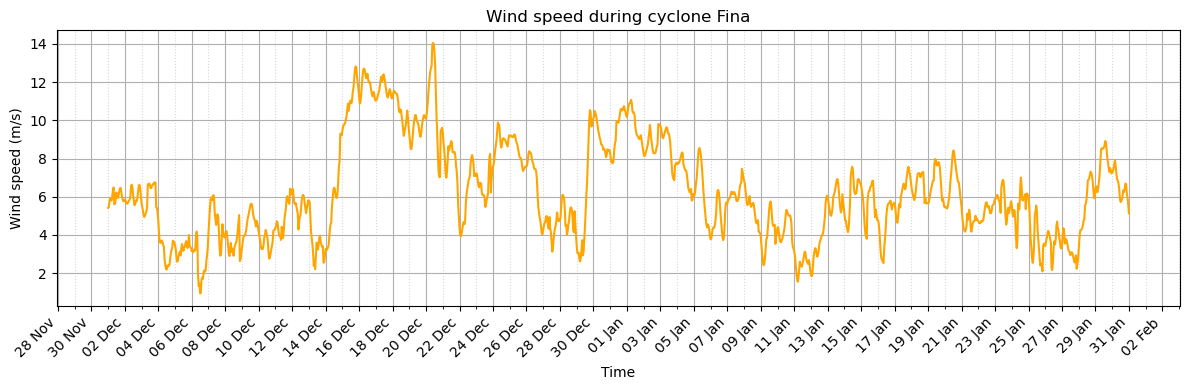

In [63]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_fina.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Fina")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

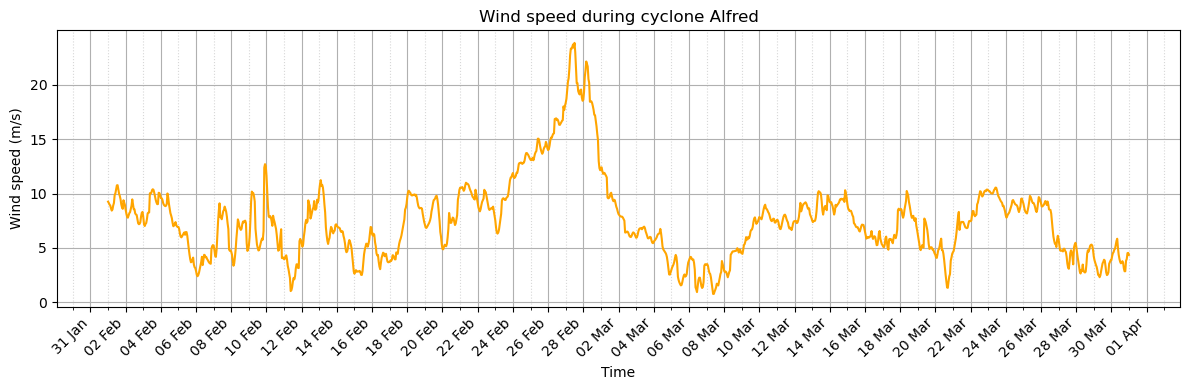

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_alfred.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Alfred")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

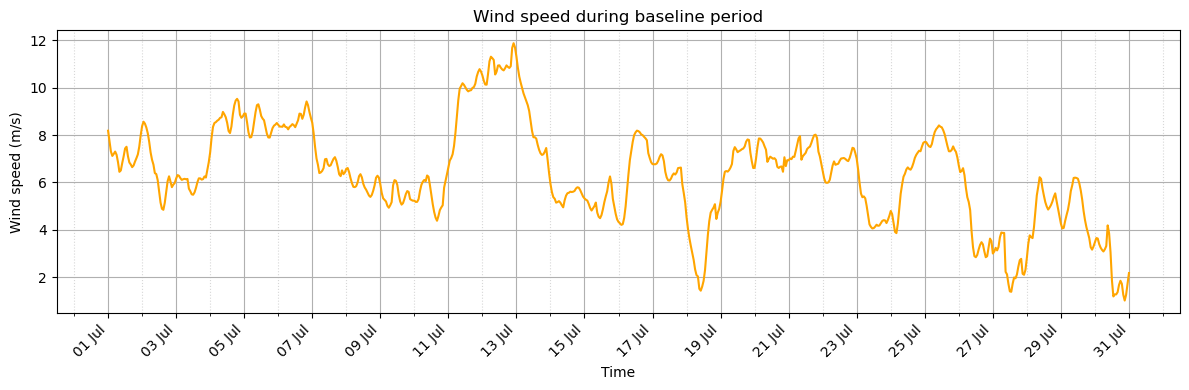

In [65]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_baseline_july.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during baseline period")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Wave analysis

In [34]:
wave_fina=xr.open_dataset('data/wave_fina.nc')
wave_alfred=xr.open_dataset('data/wave_alfred.nc')
wave_baseline=xr.open_dataset('data/wave_baseline.nc') 
list(wave_fina.variables)

['time', 'latitude', 'longitude', 'VHM0']

In [35]:
height_fina=wave_fina['VHM0']
height_alfred=wave_alfred['VHM0']
height_baseline=wave_baseline['VHM0']
print(height_fina)

<xarray.DataArray 'VHM0' (time: 489, latitude: 5, longitude: 5)> Size: 49kB
[12225 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4kB 2011-12-01 ... 2012-01-31
  * latitude   (latitude) float32 20B -19.4 -19.2 -19.0 -18.8 -18.6
  * longitude  (longitude) float32 20B 155.2 155.4 155.6 155.8 156.0
Attributes:
    units:             m
    standard_name:     sea_surface_wave_significant_height
    long_name:         Spectral significant wave height (Hm0)
    WMO_code:          100
    cell_methods:      time:point area:mean
    type_of_analysis:  spectral analysis


In [ ]:
wave_ts_fina = height_fina.mean(dim=("latitude", "longitude"))

print("Max wave height during cyclone Fina:", wave_ts_fina.max().values, "m")
wave_ts_alfred = height_alfred.mean(dim=("latitude", "longitude"))
print("Max wave height during cyclone Alfred:", wave_ts_alfred.max().values, "m")
wave_ts_baseline = height_baseline.mean(dim=("latitude", "longitude"))
wave_ts_baseline_july = wave_ts_baseline.sel(time=slice("2025-07-01", "2025-07-31"))

Max wave height during cyclone Fina: 3.0927999019622803 m
Max wave height during cyclone Alfred: 8.970800399780273 m


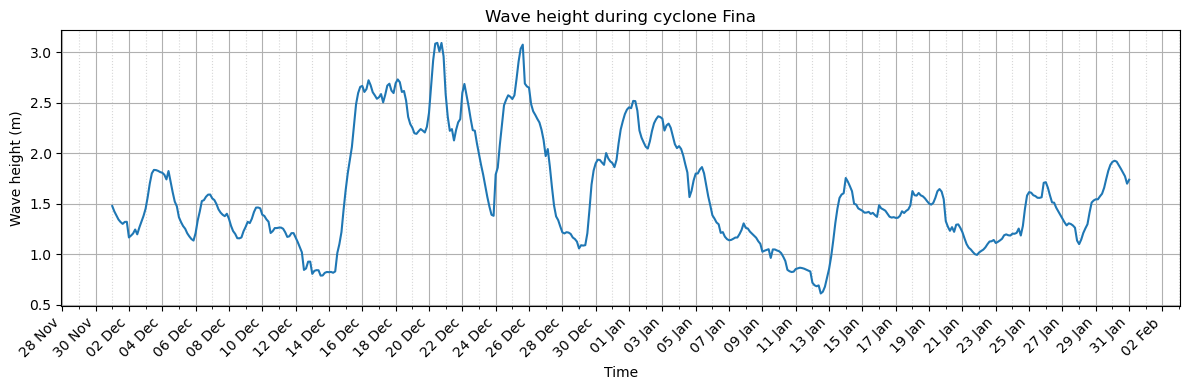

In [52]:
fig, ax = plt.subplots(figsize=(12, 4))

wave_ts_fina.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wave height during cyclone Fina")
ax.set_ylabel("Wave height (m)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

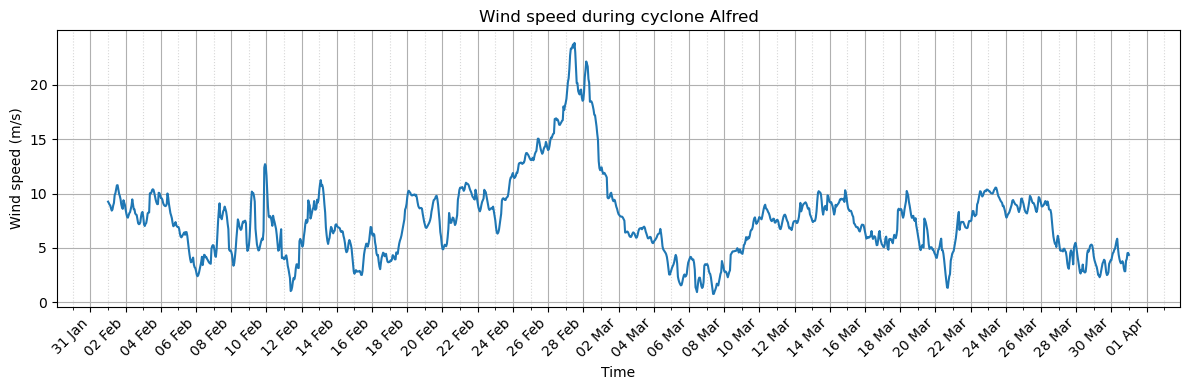

In [53]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_alfred.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Alfred")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

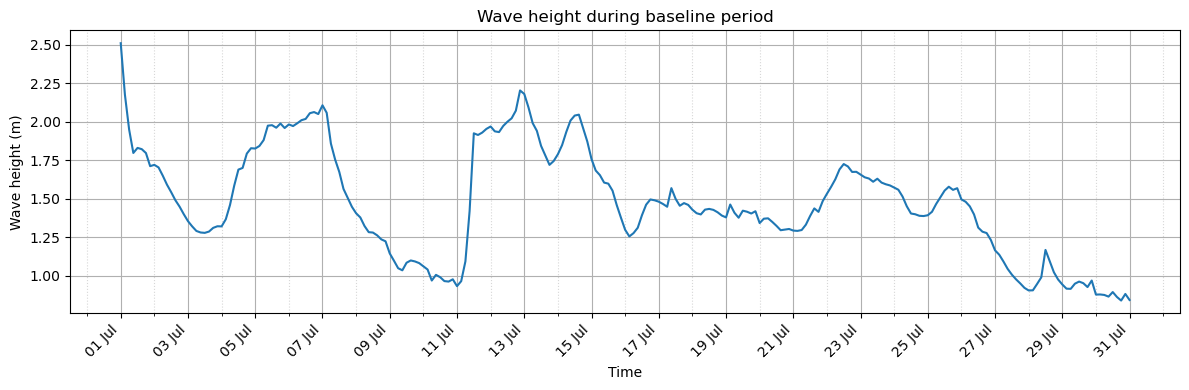

In [54]:
fig, ax = plt.subplots(figsize=(12, 4))

wave_ts_baseline_july.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wave height during baseline period")
ax.set_ylabel("Wave height (m)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Combined analysis

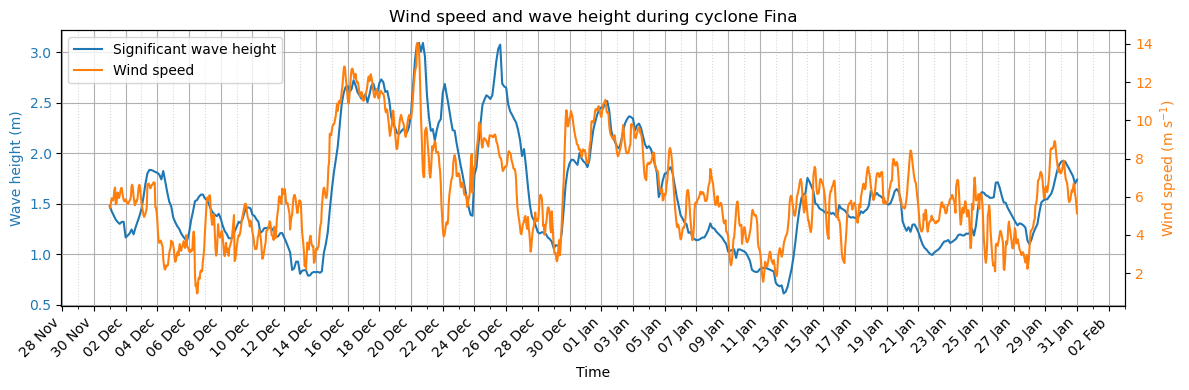

In [58]:
#Fina
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_fina.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_fina.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during cyclone Fina")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()


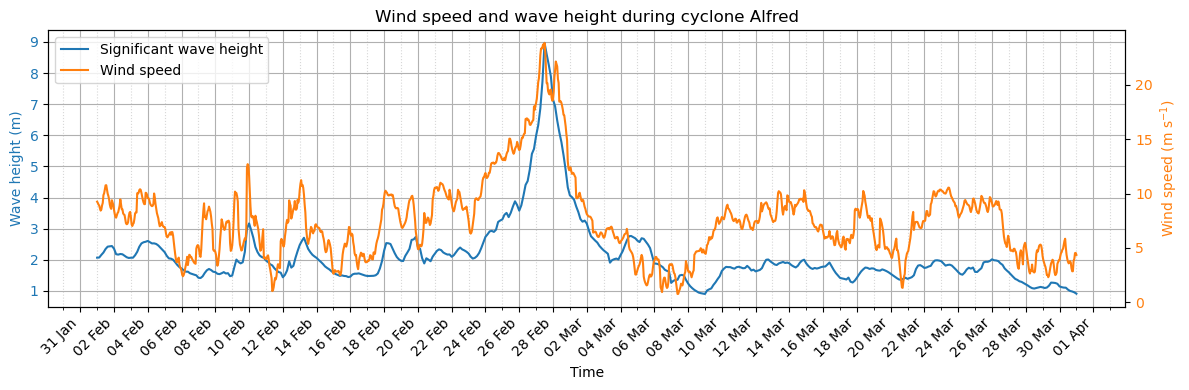

In [59]:
#Alfred
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_alfred.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_alfred.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during cyclone Alfred")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()


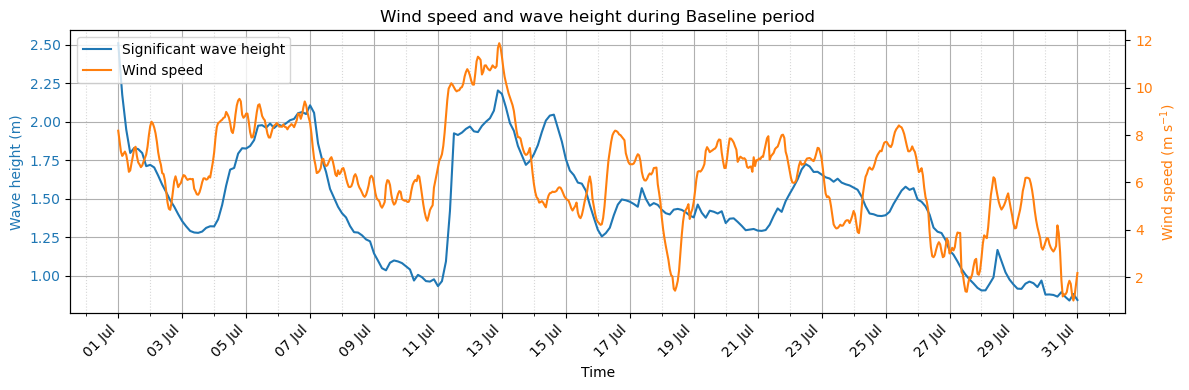

In [61]:
#baseline
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_baseline_july.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_baseline_july.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during Baseline period")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

